# Tutorial 1: Simulation of FOV-Induced Incomplete Registration in Human Tonsil

This tutorial uses paired RNA and ADT profiles from human tonsil, available through the [SpaMosaic dataset on Zenodo](https://zenodo.org/records/18946723). In this source-to-target setting, RNA is retained as the complete source modality, whereas a contiguous ADT region is masked to simulate FOV-induced incomplete registration, reflecting real spatial multi-omics experiments with unequal or only partially overlapping modality coverage. Because the original profiles are paired, the masked ADT measurements provide location-matched ground truth for quantitative evaluation of PRISM completion.

In [1]:
from pathlib import Path

import scanpy as sc
import PRISM
from PRISM import (compute_similarity_prior, plot_per_protein_correlations, plot_prism_imputation_spatial,
                   preprocess_omics, prism_eval_and_save, run_clustering_eval_plot, select_best_device,
                   set_prism_plot_style, set_seed, simulate_missing_sliding)
set_prism_plot_style()

DEVICE = select_best_device()
RANDOM_SEED = 2024
set_seed(RANDOM_SEED)


### Load data

`Slice_ID` selects the tonsil section (`S2` by default; `S1` and `S3` are also available). This cell defines the corresponding input and output paths, then loads the paired RNA and ADT profiles used in the simulation.

In [2]:
Slice_ID = "S2"
DATASET_DIR = Path("Datasets") / "human lymphoid organs" / "tonsil" / Slice_ID
SOURCE_H5AD = DATASET_DIR / "adata_RNA.h5ad"
TARGET_H5AD = DATASET_DIR / "adata_ADT.h5ad"
RESULTS_DIR = Path("Results") / "Tutorial1_human_tonsil"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PRIOR_PATH = RESULTS_DIR / f"{Slice_ID}_tonsil_AOT.npz"
RUN_PREFIX = f"{Slice_ID}_tonsil"

adata_source = sc.read_h5ad(SOURCE_H5AD)
adata_target = sc.read_h5ad(TARGET_H5AD)
adata_source.var_names_make_unique()
adata_target.var_names_make_unique()

### Simulating incomplete registration

`simulate_missing_sliding` provides a general framework for simulating controlled source-to-target incomplete registration from paired spatial multi-omics data. It emulates technical coverage mismatch in which the source assay spans the tissue, whereas the target assay has a smaller, shifted or partially overlapping field of view, as can arise from different acquisition windows, tissue cropping or restricted target-modality coverage.

The simulation modifies target availability rather than the underlying biology: source measurements remain available, selected target measurements are withheld from PRISM, and the original target profiles are retained as location-matched ground truth. `missing='0'` denotes a target-unregistered location and `missing='1'` denotes an observed source-target pair.

In this tutorial, RNA remains observed throughout the paired tonsil section and serves as the complete source modality. A contiguous ADT region is designated as target-unregistered, so the corresponding locations retain RNA but have no ADT available to PRISM during training. This simulates FOV-induced target coverage loss rather than biological protein absence.

`simulate_missing_sliding` controls the technical pattern of target field-of-view mismatch:

| Setting | Role and technical interpretation |
| --- | --- |
| `direction` | `"H"` or `"V"` defines the orientation of a contiguous target-coverage loss, emulating directional cropping or a shifted target acquisition window along the horizontal or vertical tissue axis. `"R"` represents dispersed target loss across the whole section, whereas `"RW"` represents heterogeneous loss within a locally restricted acquisition area. |
| `missing_width` | Sets the fraction of target locations outside the effective target field of view. Larger values emulate more severe coverage mismatch between source and target assays. |
| `step_ratio`, `step_id` | Control the relative displacement and position of the target field of view. They model different spatial offsets between source and target acquisition windows and allow positional sensitivity to be examined reproducibly. |
| `lock_at_end` | Constrains the simulated target field of view to the sampled tissue extent when the window reaches a boundary. |
| `spatial_key` | Specifies the physical coordinate system in which the field-of-view mismatch is simulated. |
| `label_key` | Specifies where target availability is recorded for subsequent preprocessing and PRISM training. |

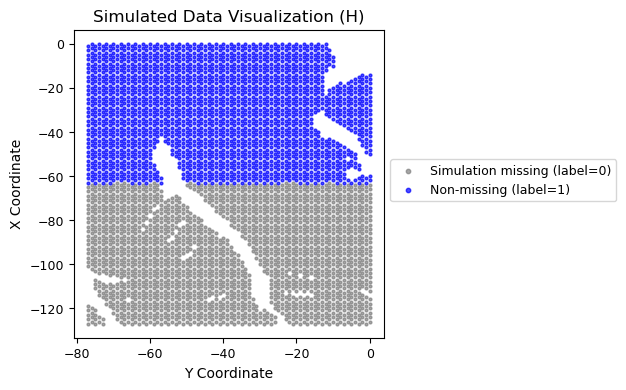

ADT missing cells: 2259/4519


In [3]:
missing_indices = simulate_missing_sliding(adata_target, spatial_key="spatial", direction="H", missing_width=0.50, 
                                           step_ratio=0.10, step_id=0, label_key="missing", lock_at_end=True,
                                           point_size=4, plot=True, figsize=(4, 4))

print(f"ADT missing cells: {len(missing_indices)}/{adata_target.n_obs}")

### Preprocessing source and target modalities

`preprocess_omics` provides modality-specific preprocessing for PRISM while retaining the registration-availability label needed to distinguish observed and target-unregistered locations. In this tutorial, RNA is prepared as the complete source modality and ADT as the partially observed target modality. The FOV-derived `missing` labels are carried into the processed target object as an availability mask, so unavailable ADT locations cannot be treated as observed RNA-ADT pairs during subsequent PRISM training.

In [4]:
adata_source, _ = preprocess_omics(adata_source, modality="RNA", missing_key="missing", min_cells=10, 
                                   hvgs=3000, data_role="source", compute_pca=False, save_raw_eval=False)

adata_target, _ = preprocess_omics(adata_target, modality="ADT", missing_key="missing", data_role="target",
                                   compute_pca=False, save_log_layer=False, save_raw_eval=True)

print("RNA shape after preprocessing:", adata_source.shape)
print("ADT shape after preprocessing:", adata_target.shape)

RNA shape after preprocessing: (4519, 3000)
ADT shape after preprocessing: (4519, 31)


### Computing a niche-informed similarity prior

`compute_similarity_prior` is PRISM's unified routine for constructing a within-section spatial-niche prior. COVET summarizes each source location through the covariance structure of its local molecular neighbourhood, and approximate optimal transport (AOT) compares these neighbourhoods to identify locations with analogous tissue context. The resulting prior supplies contextual reference locations for target-unregistered queries during PRISM training.

The availability label enables the same workflow to accommodate incomplete source data without interpreting unavailable profiles as molecular signal. In this tutorial, RNA is complete, so all RNA profiles contribute to COVET and AOT construction. The simulated ADT FOV mask subsequently determines which RNA-ADT pairs are available as observed target references and which locations require ADT completion.

COVET was introduced in the [original paper](https://doi.org/10.1038/s41587-024-02193-4); see the [official code](https://github.com/dpeerlab/ENVI) and [tutorial](https://scenvi.readthedocs.io/) for the reference implementation.

| Setting | Role in this tutorial |
| --- | --- |
| `covet_k_spatial=6` | Defines the local spatial neighbourhood used to estimate each RNA covariance environment. |
| `covet_gene_num=64` | Sets the number of source RNA features used to construct the covariance environment. |
| `spatial_key="spatial"` | Specifies the tissue coordinates used to define local RNA neighbourhoods. |
| `missing_key="missing"` | Supplies modality availability information. It allows the same routine to exclude unavailable source profiles in incomplete-source settings; here it confirms that RNA is fully observed. |

In [5]:
distance_matrix, prior_metrics = compute_similarity_prior(adata_source, adata_target, PRIOR_PATH, device=DEVICE,
                                                          covet_k_spatial=6, covet_gene_num=64, spatial_key="spatial", 
                                                          missing_key="missing", store_neighbor_index=True, 
                                                          show_prior_metrics=True)

Step 1: src COVET
Using the top 64 genes from the pre-calculated HVG ranking for COVET
Computing COVET using 64 genes
Using expression data from layer 'log'
Calculating covariance matrices for all cells/spots
Computing matrix square root.
[COVET | auto missing-aware mode]
Original n_obs : 4519
Reference n_obs: 4519
has missing    : False
missing cells  : 0
observed cells : 4519
k_spatial used     : 6
batch_key used     : -1
COVET shape        : (4519, 64, 64)
COVET_SQRT shape   : (4519, 64, 64)
Number of CovGenes : 64

Step 2: src AOT
[AOT] representation=full COVET_SQRT flatten
[AOT] n=4519, d=4096, k_env=4518, backend=torch
[AOT] distances stored are squared Euclidean/Frobenius distances.
[AOT/torch] device=cuda:1
[AOT/torch] processed 4519/4519
[AOT] saved adata.obsp['aot_distances_ref'] shape=(4519, 4519), nnz=20416842
[AOT | auto missing-aware mode]
Reference AOT shape      : (4519, 4519)
Reference AOT nnz        : 20416842
Original-space AOT shape : (4519, 4519)
Original-space AO

### Constructing spatial graphs

PRISM constructs a modality-specific spatial graph to encode local neighbourhood structure; `Cal_Spatial_Net` supports radius-based and k-nearest-neighbour (KNN) edges, and this tutorial uses the radius-based option.

------Calculating spatial graph...
The graph contains 34440 edges, 4519 cells.
7.6212 neighbors per cell on average.


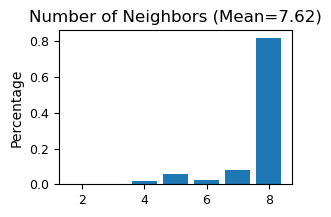

------Calculating spatial graph...
The graph contains 34440 edges, 4519 cells.
7.6212 neighbors per cell on average.


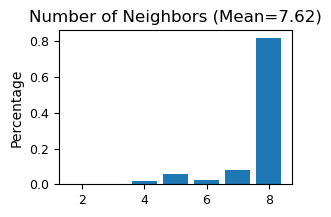

In [6]:
PRISM.Cal_Spatial_Net(adata_source, rad_cutoff=2)
PRISM.Stats_Spatial_Net(adata_source)

PRISM.Cal_Spatial_Net(adata_target, rad_cutoff=2)
PRISM.Stats_Spatial_Net(adata_target)

### Training PRISM

In this source-to-target setting, `missing` marks unavailable target profiles, which are represented internally by learnable imputation tokens. The adapted COVET/AOT prior retrieves `k_top` registered references, and the Transformer organizes them with each query into a sequence that propagates information to target-unregistered locations.

`n_epochs` defines the maximum training budget, while `min_epochs` ensures a minimum optimization period before loss-based early stopping controlled by `patience`. `center_drop_rate` temporarily masks observed target centres as a training augmentation, and the optional `interaction_pca` appends PCA-compressed source-target interaction features to the final PRISM embedding.

The resulting `PRISM_emb` supports spatial-domain identification (Task 1), whereas the modality-specific decoders provide missing-omics imputation (Task 2).

In [7]:
adata_source_out, adata_target_out = PRISM.train_PRISM(adata_source, adata_target, distance_matrix, 
                                                       k_top=5, n_epochs=1000, lr=1e-3, 
                                                       output_dir=str(RESULTS_DIR), file_prefix=RUN_PREFIX,
                                                       device=DEVICE, patience=20, min_epochs=50,
                                                       center_drop_rate=0.1, noise=0.0,
                                                       load_model_path=False, interaction_pca=True)

Similarity prior ready: 4519 cells, 5 observed neighbors per cell.



>>> Early stopping at epoch 263.
PRISM training and inference complete: S2_tonsil


### Task 1: Spatial-domain identification

Task 1 identifies spatial domains by clustering `PRISM_emb` and evaluates agreement with the reference domain annotation using adjusted mutual information (AMI), V-measure, mutual information, homogeneity, normalized mutual information (NMI) and adjusted Rand index (ARI).

fitting ...
  |======================================================================| 100%
Domain clustering metrics: {'embedding': 'PRISM_emb', 'cluster_key': 'PRISM_mclust', 'AMI': 0.3247, 'V_measure': 0.3253, 'Mutual_info': 0.3269, 'Homogeneity': 0.2994, 'NMI': 0.3253, 'ARI': 0.3379}


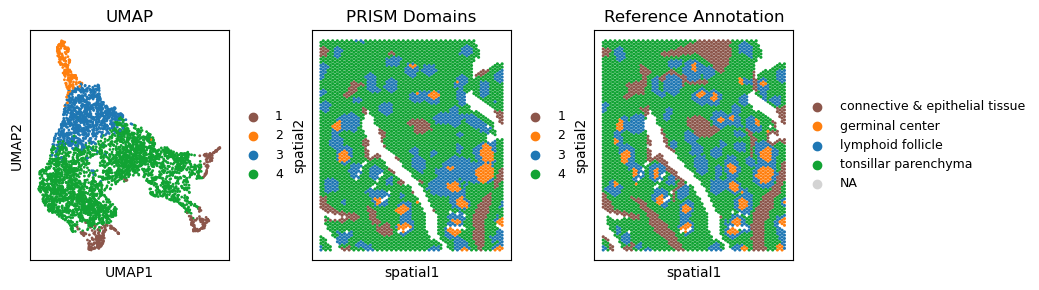

In [ ]:
adata_clustered, domain_metrics = run_clustering_eval_plot(adata_source_out, emb_key="PRISM_emb", label_key="final_annot",
                                                           cluster_key="PRISM_mclust", n_clusters=4, s=20, use_pca=True,
                                                           align_labels=True, aligned_key="PRISM_mclust_domain",
                                                           dataset_name="tonsil")

### Task 2: Missing-omics (ADT) imputation

Task 2 evaluates ADT imputation at simulated target-unregistered locations using the pre-masking profiles as ground truth. Overall performance is summarized by the Pearson correlation coefficient (PCC), Spearman correlation coefficient (SPCC) and mean squared error (MSE), reported across proteins as mean +/- s.d.; per-protein correlation plots show variation across the ADT panel. `save_files=True` writes the raw-scale, fully imputed AnnData object together with location-level truth and prediction matrices and feature-level metric summaries.

Imputation metrics (mean +/- s.d.): PCC=0.6751 +/- 0.1618, SPCC=0.6595 +/- 0.1593, MSE=0.0260 +/- 0.0319
Missing observations: 2259


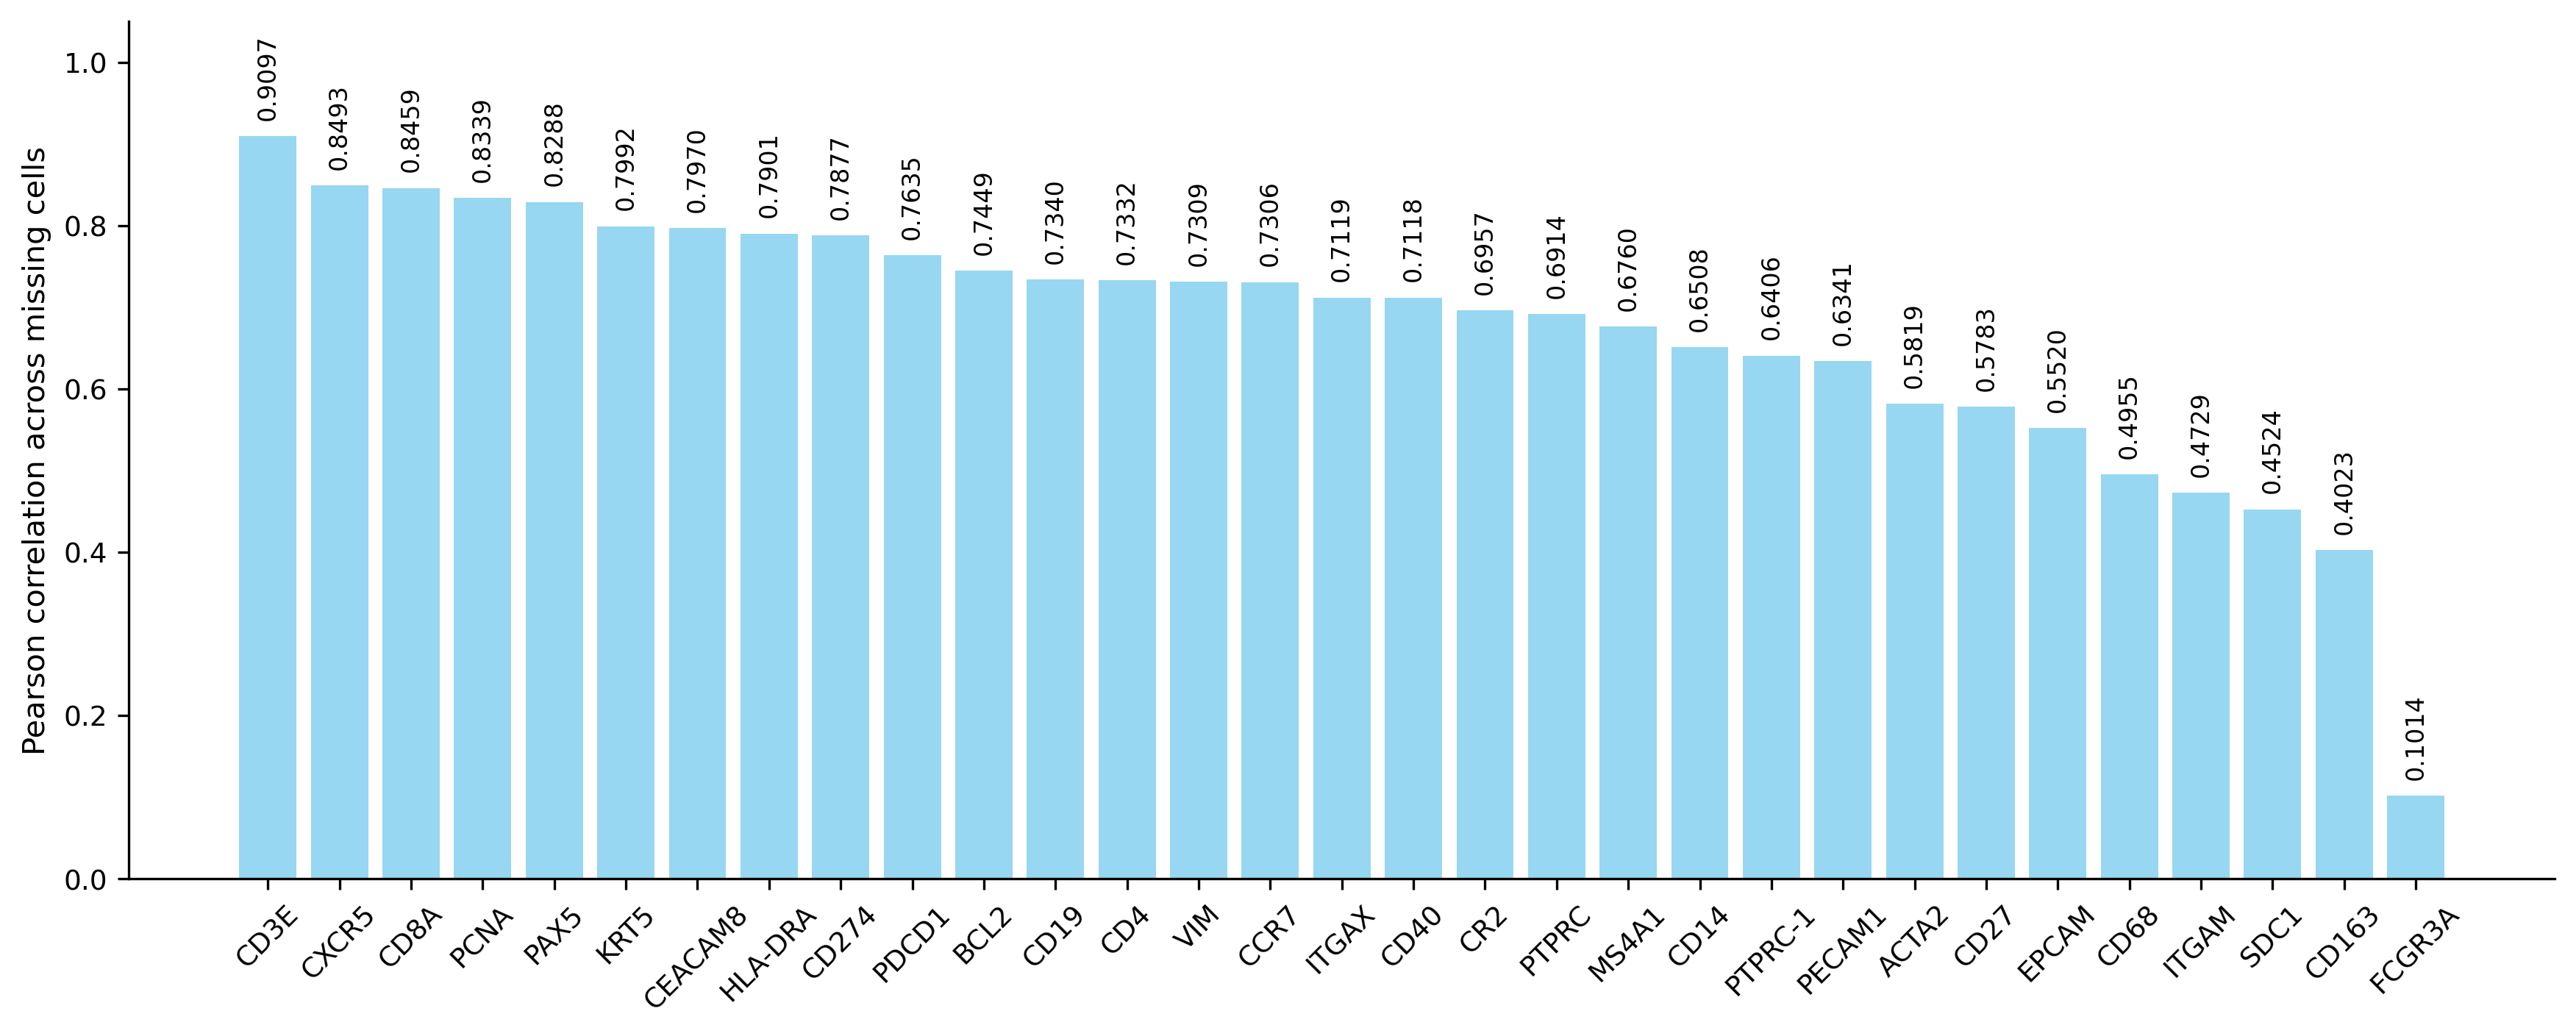

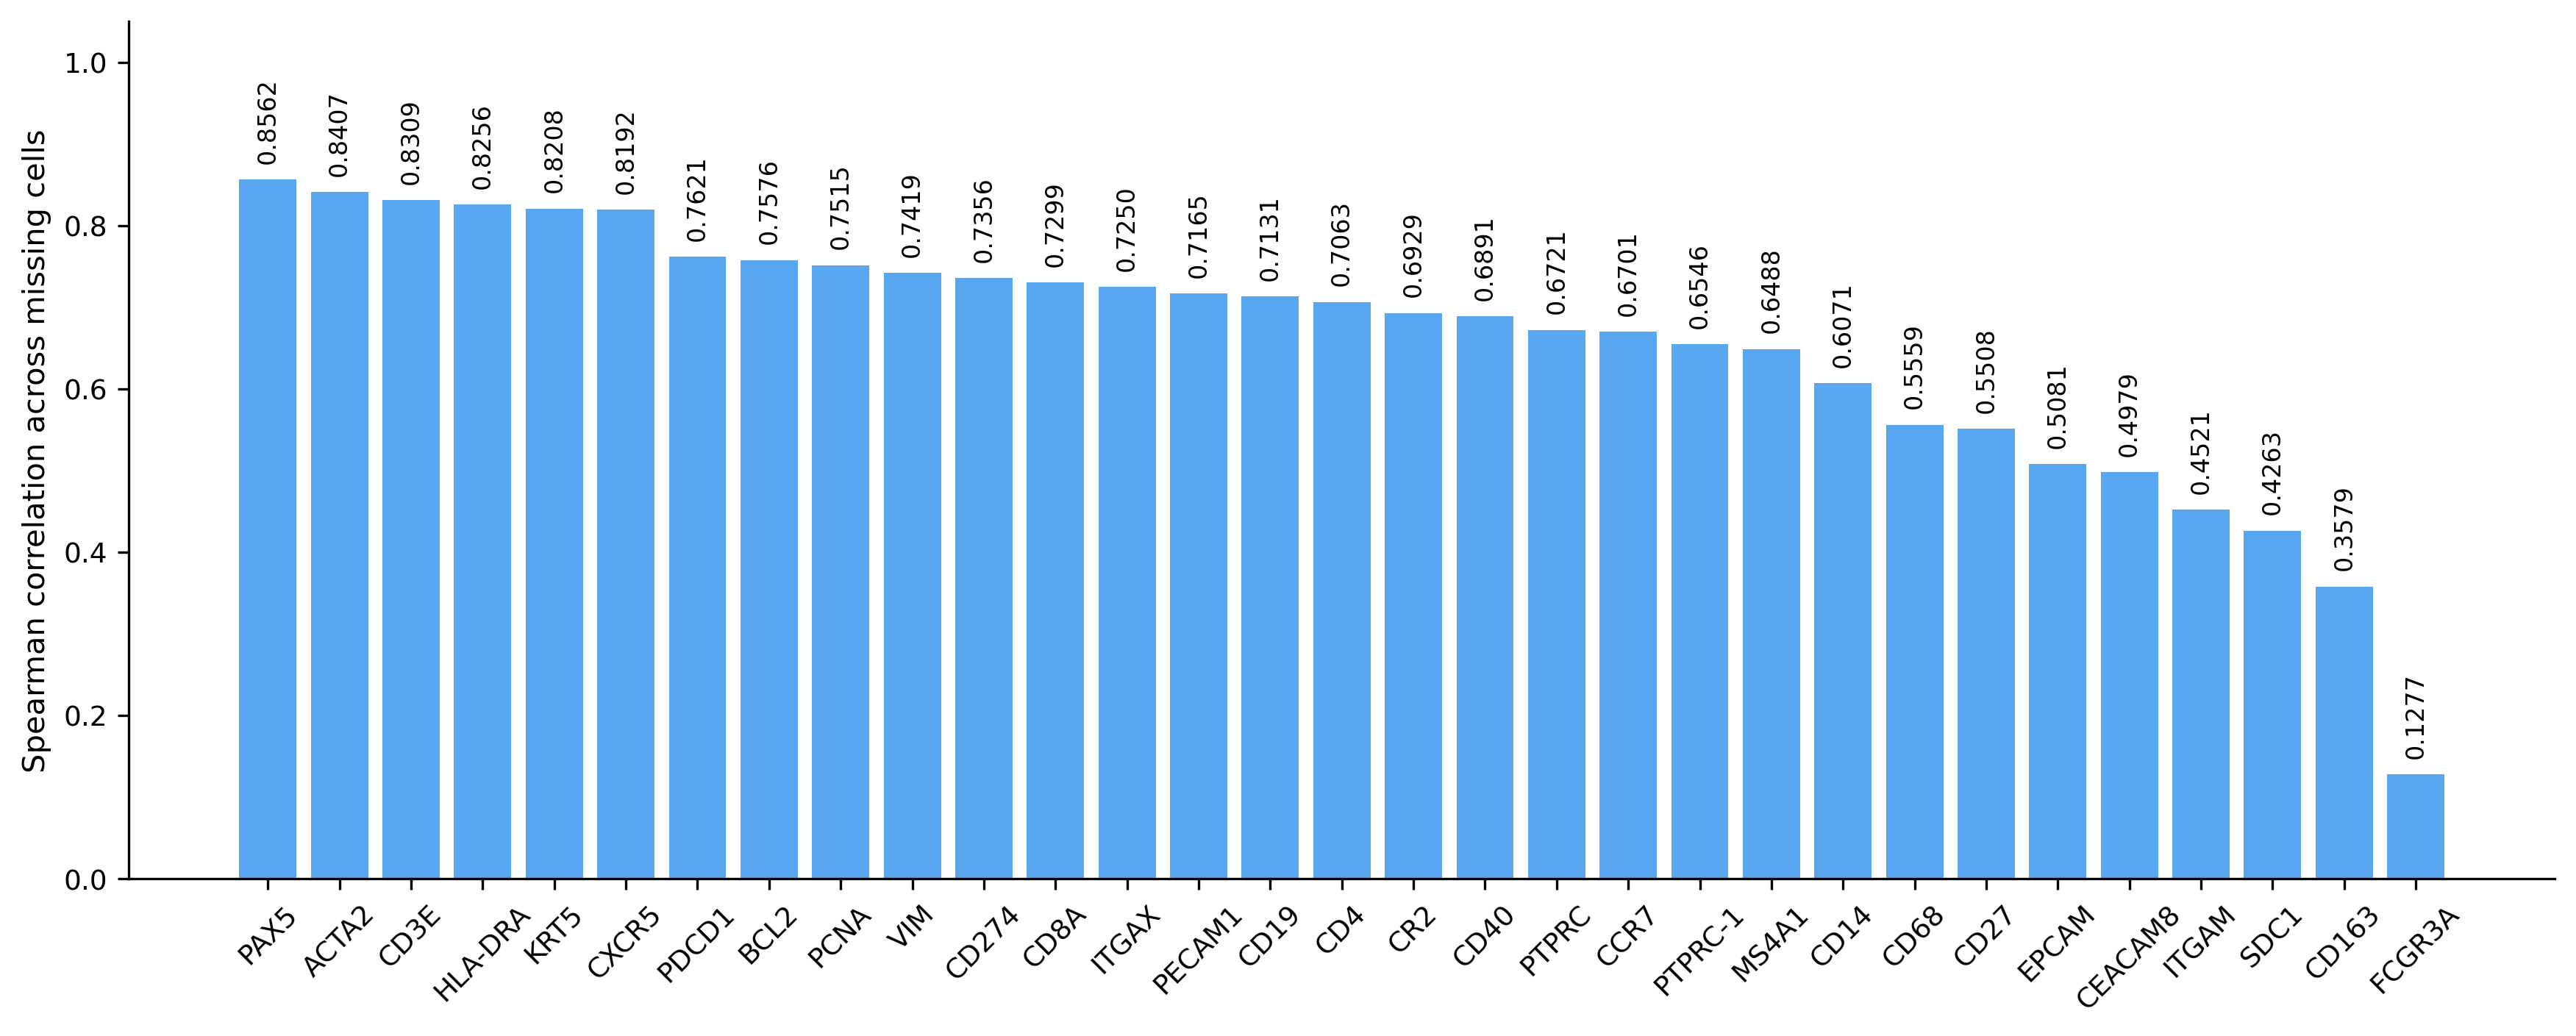

In [9]:
# Evaluate overall ADT imputation performance
imputation_results = prism_eval_and_save(truth_adata=adata_target_out, adata=adata_target_out, 
                                         save_path=str(RESULTS_DIR), first_name=RUN_PREFIX,
                                         missing_indices=missing_indices,
                                         save_files=True)

# Display per-protein PCC and SPCC
per_protein_figures = plot_per_protein_correlations(imputation_results, feature_names=adata_target.var_names)

Representative ADT protein CD3E: {'PCC': 0.9097, 'SPCC': 0.8309, 'MSE': 0.0035}


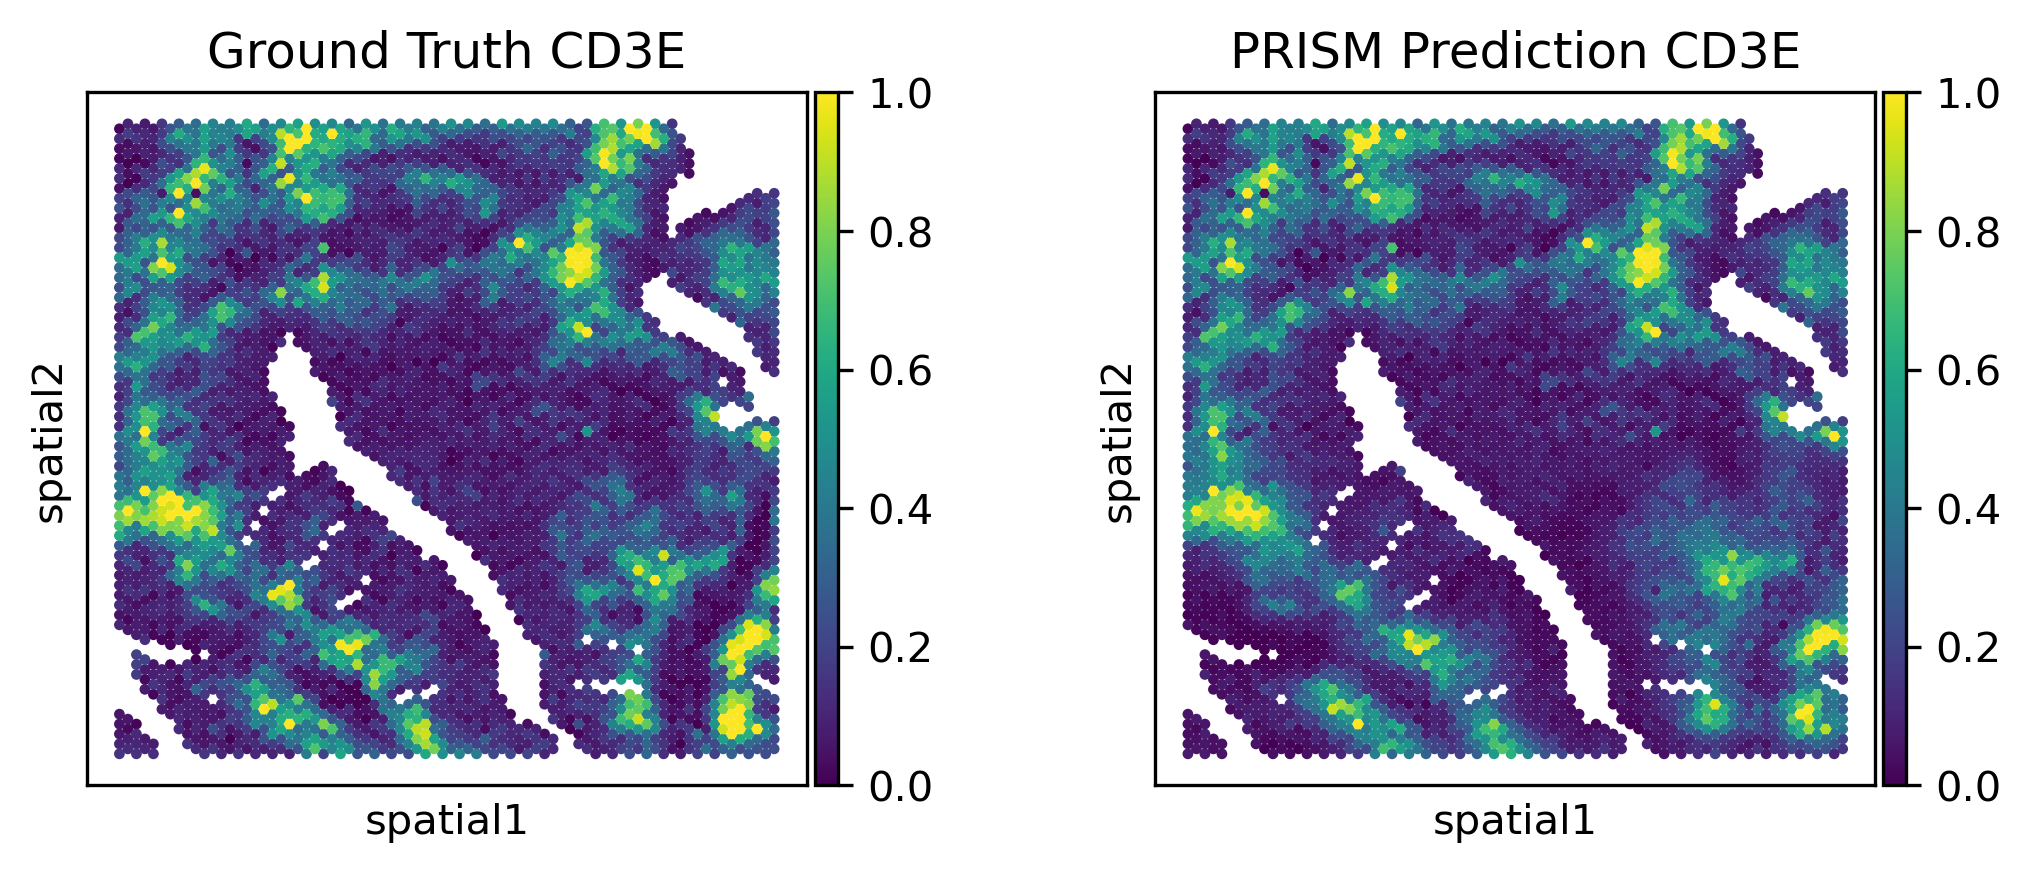

In [10]:
# Visualize representative ADT protein imputation
FEATURE_TO_PLOT = "CD3E"

fig, axs = plot_prism_imputation_spatial(imputation_results=imputation_results, split1_indices=missing_indices,
                                         feature=FEATURE_TO_PLOT, show_missing_only=False, highlight_missing=False,
                                         figsize=(8, 3))

feature_idx = adata_target.var_names.get_loc(FEATURE_TO_PLOT)
feature_metrics = {metric: round(float(imputation_results["raw"]["per_protein"][metric][feature_idx]), 4)
                   for metric in ("PCC", "SPCC", "MSE")}
print(f"Representative ADT protein {FEATURE_TO_PLOT}: {feature_metrics}")